# Dubois surface inversion tutorial


This notebook shows how to run the Dubois surface inversion on a UAVSAR multilooked GRD covariance product together with a matching incidence-angle raster.


## How the input product was prepared

The example data used here were prepared in three steps:

- Download the free UAVSAR multilooked GRD covariance product from the UAVSAR data archive.
- Import the covariance product into ESA SNAP and export it to NetCDF-BEAM format.
- Download the matching incidence-angle file for the same scene.
- Download the annotation file (.ann) to retrieve the dimension of the incidence angle raster.

In the notebook below we read the NetCDF-BEAM covariance product with `open_netcdf_beam`, load the incidence-angle raster, align both rasters to the multilooked grid, and then pass them to `dubois_surface_inversion`.


## Import packages and set directories


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import xarray as xr
from dask.diagnostics import ProgressBar

from polsarpro.io import open_netcdf_beam
from polsarpro.physical_inversion import dubois_surface_inversion

# change these paths to match your local files
input_uavsar_nc = Path('/data/psp/test_files/blackw_20801_22010_006_220507_L090_CX_02_ML5X5.nc')
incidence_angle_file = Path('/data/psp/test_files/blackw_20801_22010_006_220507_L090_CX_02.inc')
output_dir = Path('/data/psp/res')
output_dir.mkdir(parents=True, exist_ok=True)
file_out = output_dir / 'dubois_surface_inversion_uavsar.nc'

# Dubois expects GHz; the UAVSAR metadata stores the center wavelength in cm.
with xr.open_dataset(input_uavsar_nc) as raw_ds:
    center_wavelength_cm = raw_ds['metadata'].attrs['Annotation:CenterWavelength']

freq_ghz = 29.9792458 / float(center_wavelength_cm)

# Example parameter values used for this UAVSAR scene.
thresh1_db = -5.0
thresh2_db = 0.0
calibration_coeff = 1.0

print(f'Derived radar frequency: {freq_ghz:.6f} GHz')


Derived radar frequency: 1.257500 GHz


## Load the input product


In [2]:
C3 = open_netcdf_beam(input_uavsar_nc)
row_dim, col_dim = C3.dims

# Use the values from the UAVSAR annotation file.
# inc.set_rows (pixels) = 12344 ; INC Lines
# inc.set_cols (pixels) = 11248 ; INC Samples
nlines = 12344
ncols = 11248

# The incidence-angle file is a little-endian float32 stream in radians.
# Read only the raster-sized prefix and reshape it to the UAVSAR grid.
incidence_angle_values = np.fromfile(
    incidence_angle_file,
    dtype='<f4',
    count=nlines * ncols,
)
incidence_angle_values[incidence_angle_values == -10000] = np.nan
incidence_angle = xr.DataArray(
    incidence_angle_values.reshape(nlines, ncols),
    dims=(row_dim, col_dim),
    name='incidence_angle',
).coarsen(y=5, x=5, boundary='trim').mean()


## Apply the inversion


In [3]:
if file_out.exists():
    file_out.unlink()

with ProgressBar():
    out_py = dubois_surface_inversion(
        C3,
        incidence_angle=incidence_angle,
        freq_ghz=freq_ghz,
        thresh1=thresh1_db,
        thresh2=thresh2_db,
        calibration_coeff=calibration_coeff,
    )
    out_py.to_netcdf(file_out)


[########################################] | 100% Completed | 5.32 ss


## Inspect the output


In [4]:
res = xr.open_dataset(file_out)
res


<xarray.Dataset> Size: 133MB
Dimensions:                   (y: 2468, x: 2249)
Coordinates:
  * y                         (y) int64 20kB 0 1 2 3 4 ... 2464 2465 2466 2467
  * x                         (x) int64 18kB 0 1 2 3 4 ... 2245 2246 2247 2248
Data variables:
    dubois_ks                 (y, x) float32 22MB ...
    dubois_er                 (y, x) float32 22MB ...
    dubois_mv                 (y, x) float32 22MB ...
    dubois_mask_out           (y, x) float32 22MB ...
    dubois_mask_in            (y, x) float32 22MB ...
    dubois_mask_valid_in_out  (y, x) float32 22MB ...
Attributes:
    poltype:      dubois_surface_inversion
    description:  Results of the Dubois surface inversion.

You can also plot the main Dubois outputs directly:


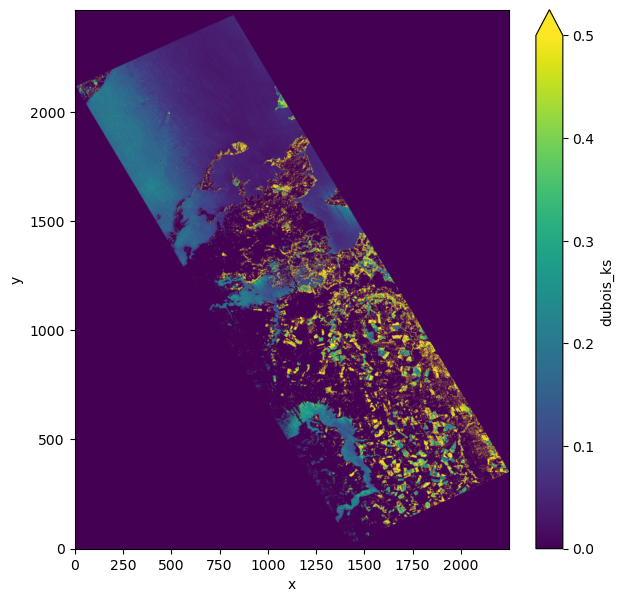

In [10]:
res.dubois_ks.plot.imshow(cmap='viridis', vmax=0.5, interpolation="bilinear", figsize=(7,7))

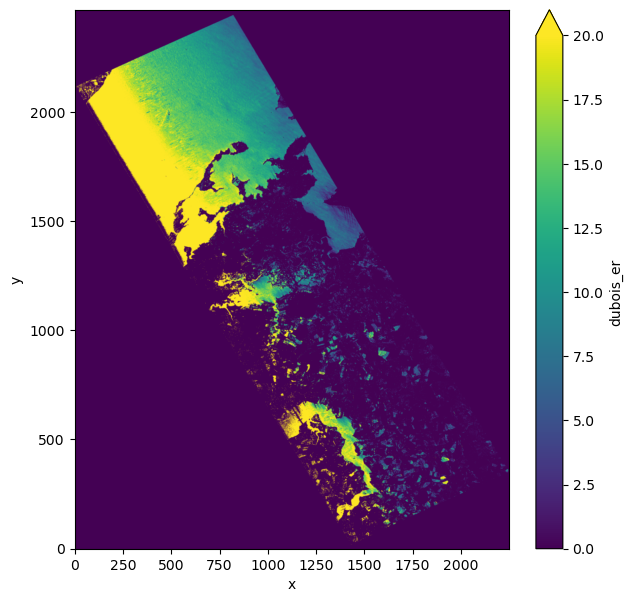

In [16]:
res.dubois_er.plot.imshow(cmap='viridis', vmax=20, interpolation="bilinear", figsize=(7,7))